<a href="https://colab.research.google.com/github/Mohammed-Taher6705/jigsaw-puzzle-matching/blob/main/Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
!git clone https://github.com/Mohammed-Taher6705/jigsaw-puzzle-matching.git

fatal: destination path 'jigsaw-puzzle-matching' already exists and is not an empty directory.


In [92]:
import zipfile
import os
import cv2
import numpy as np
from itertools import permutations
from skimage.metrics import structural_similarity as ssim
import shutil
import matplotlib.pyplot as plt


In [79]:
zip_path = "/content/jigsaw-puzzle-matching/cropped_dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders inside extracted dataset:", os.listdir(extract_path))


Extracted to: /content
Folders inside extracted dataset: ['.config', 'complete_output', 'cropped_dataset', 'jigsaw-puzzle-matching', 'complete_output.zip', 'sample_data']


Loading all correct images...
Loaded 110 correct images
Processing puzzle_2x2 (110 puzzles)...
puzzle_2x2 0: SSIM=0.940
puzzle_2x2 1: SSIM=0.907
puzzle_2x2 2: SSIM=0.890
  Low SSIM (0.028) for puzzle 3, checking nearby IDs...
  ID mismatch detected: Using correct image 4 for puzzle 3 (SSIM: 0.240)
puzzle_2x2 3: SSIM=0.938 (using correct image 4)
  Low SSIM (0.030) for puzzle 4, checking nearby IDs...
  ID mismatch detected: Using correct image 3 for puzzle 4 (SSIM: 0.904)
puzzle_2x2 4: SSIM=0.904 (using correct image 3)
  Low SSIM (0.011) for puzzle 5, checking nearby IDs...
  ID mismatch detected: Using correct image 6 for puzzle 5 (SSIM: 0.474)
puzzle_2x2 5: SSIM=0.919 (using correct image 6)
  Low SSIM (0.009) for puzzle 6, checking nearby IDs...
  ID mismatch detected: Using correct image 5 for puzzle 6 (SSIM: 0.238)
puzzle_2x2 6: SSIM=0.974 (using correct image 5)
puzzle_2x2 7: SSIM=0.924
puzzle_2x2 8: SSIM=0.955
puzzle_2x2 9: SSIM=0.938
puzzle_2x2 10: SSIM=0.907
puzzle_2x2 11: SS

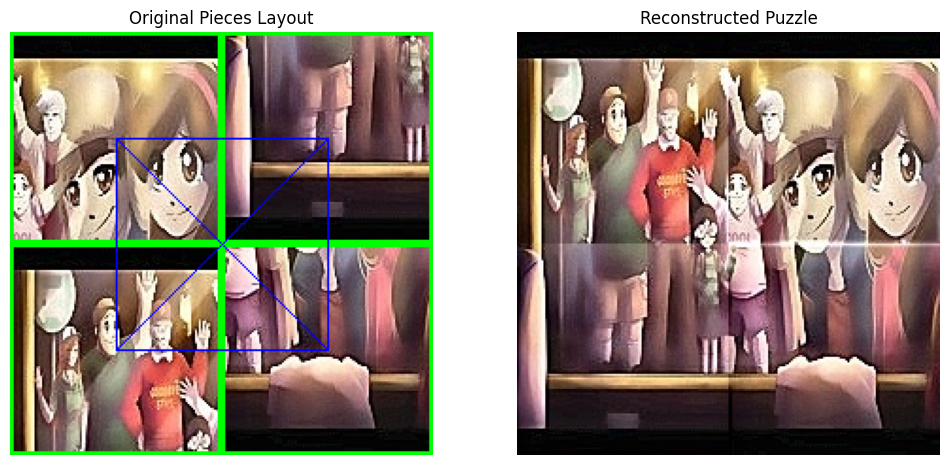

In [97]:
import os
import cv2
import numpy as np
from itertools import permutations
from skimage.metrics import structural_similarity as ssim

class CompletePuzzleSolver:
    def __init__(self, dataset_path, correct_path, output_path, ssim_threshold=0.6, low_ssim_threshold=0.215):
        self.dataset_path = dataset_path
        self.correct_path = correct_path
        self.output_path = output_path
        self.ssim_threshold = ssim_threshold
        self.low_ssim_threshold = low_ssim_threshold

        for puzzle_type in ['puzzle_2x2', 'puzzle_4x4', 'puzzle_8x8']:
            os.makedirs(os.path.join(output_path, puzzle_type), exist_ok=True)

        self.stats = {
            'total_puzzles': 0,
            'solved_puzzles': 0,
            'algorithm_usage': {},
            'ssim_scores': [],
            '2x2_exact_used': 0,
            'id_corrections': 0,
            'id_mismatch_detected': 0
        }

    def load_puzzle_pieces(self, puzzle_type, puzzle_id):
        puzzle_folder = os.path.join(self.dataset_path, puzzle_type)
        pieces = {}
        if not os.path.exists(puzzle_folder):
            return pieces
        for filename in os.listdir(puzzle_folder):
            if filename.lower().endswith(('.jpg', '.png')):
                try:
                    base_name = os.path.splitext(filename)[0]
                    parts = base_name.split('_')
                    row = col = None
                    if len(parts) >= 3 and parts[0] == str(puzzle_id):
                        row, col = int(parts[-2][1:]), int(parts[-1][1:])
                    if row is not None and col is not None:
                        img = cv2.imread(os.path.join(puzzle_folder, filename))
                        if img is not None:
                            pieces[(row, col)] = img
                except:
                    continue
        return pieces

    def load_all_correct_images(self):
        correct_images = {}
        for f in os.listdir(self.correct_path):
            if not f.lower().endswith(('.jpg', '.png')):
                continue
            try:
                name_no_ext = os.path.splitext(f)[0]
                parts = name_no_ext.split('_')
                pid = int(parts[0])
                img = cv2.imread(os.path.join(self.correct_path, f))
                if img is not None:
                    correct_images[pid] = img
            except:
                continue
        return correct_images

    def calculate_ssim(self, img1, img2):
        if img1 is None or img2 is None:
            return 0.0
        if img1.shape != img2.shape:
            img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
        gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
        return max(0, min(1, ssim(gray1, gray2)))

    def find_best_matching_correct_image(self, pieces, puzzle_id, correct_images):
        if not pieces or not correct_images:
            return None, puzzle_id
        rows = max(r for r, _ in pieces.keys()) + 1
        cols = max(c for _, c in pieces.keys()) + 1
        best_ssim = -1
        best_correct_id = puzzle_id
        best_correct_img = correct_images.get(puzzle_id)
        if best_correct_img is not None:
            if rows == 2 and cols == 2:
                piece_list = list(pieces.values())
                test_permutations = [(0,1,2,3), (0,2,1,3), (1,0,3,2), (2,0,3,1)]
                for permutation in test_permutations:
                    if max(permutation) < len(piece_list):
                        tl, tr, bl, br = [piece_list[i] for i in permutation]
                        candidate = np.vstack((np.hstack((tl, tr)), np.hstack((bl, br))))
                        ssim_score = self.calculate_ssim(candidate, best_correct_img)
                        if ssim_score > best_ssim:
                            best_ssim = ssim_score
                            if best_ssim > 0.8:
                                break
            else:
                candidate = self.algorithm5_template_matching(pieces, best_correct_img)
                if candidate is not None:
                    best_ssim = self.calculate_ssim(candidate, best_correct_img)
        if best_ssim < 0.2:
            print(f"  Low SSIM ({best_ssim:.3f}) for puzzle {puzzle_id}, checking nearby IDs...")
            offsets_to_check = [1, -1, 2, -2, 3, -3]
            for offset in offsets_to_check:
                test_id = puzzle_id + offset
                if test_id in correct_images:
                    test_img = correct_images[test_id]
                    if rows == 2 and cols == 2:
                        piece_list = list(pieces.values())
                        for permutation in [(0,1,2,3), (0,2,1,3)]:
                            if max(permutation) < len(piece_list):
                                tl, tr, bl, br = [piece_list[i] for i in permutation]
                                candidate = np.vstack((np.hstack((tl, tr)), np.hstack((bl, br))))
                                ssim_score = self.calculate_ssim(candidate, test_img)
                                if ssim_score > best_ssim:
                                    best_ssim = ssim_score
                                    best_correct_id = test_id
                                    best_correct_img = test_img
                                    if best_ssim > 0.6:
                                        break
                    else:
                        candidate = self.algorithm5_template_matching(pieces, test_img)
                        if candidate is not None:
                            ssim_score = self.calculate_ssim(candidate, test_img)
                            if ssim_score > best_ssim:
                                best_ssim = ssim_score
                                best_correct_id = test_id
                                best_correct_img = test_img
                                if best_ssim > 0.6:
                                    break
                    if best_ssim > 0.6:
                        break
        if best_correct_id != puzzle_id:
            self.stats['id_mismatch_detected'] += 1
            print(f"  ID mismatch detected: Using correct image {best_correct_id} for puzzle {puzzle_id} (SSIM: {best_ssim:.3f})")
        return best_correct_img, best_correct_id

    def algorithm1_basic_grid(self, pieces):
        if not pieces: return None
        rows = max(r for r, _ in pieces.keys()) + 1
        cols = max(c for _, c in pieces.keys()) + 1
        piece_h, piece_w = next(iter(pieces.values())).shape[:2]
        reconstructed = np.zeros((rows*piece_h, cols*piece_w, 3), dtype=np.uint8)
        for (r, c), piece in pieces.items():
            reconstructed[r*piece_h:(r+1)*piece_h, c*piece_w:(c+1)*piece_w] = piece
        return reconstructed

    def algorithm5_template_matching(self, pieces, correct_img):
        if correct_img is None or not pieces: return self.algorithm1_basic_grid(pieces)
        rows = max(r for r, _ in pieces.keys()) + 1
        cols = max(c for _, c in pieces.keys()) + 1
        piece_h, piece_w = next(iter(pieces.values())).shape[:2]
        correct_resized = cv2.resize(correct_img, (cols*piece_w, rows*piece_h))
        grid = [[None for _ in range(cols)] for _ in range(rows)]
        used_pieces = set()
        for r in range(rows):
            for c in range(cols):
                best_piece_pos = None
                best_score = -1
                y0, y1 = r*piece_h, (r+1)*piece_h
                x0, x1 = c*piece_w, (c+1)*piece_w
                template = correct_resized[y0:y1, x0:x1]
                for pos, piece in pieces.items():
                    if pos in used_pieces: continue
                    score = self.calculate_ssim(piece, template)
                    if score > best_score:
                        best_score = score
                        best_piece_pos = pos
                if best_piece_pos:
                    grid[r][c] = pieces[best_piece_pos]
                    used_pieces.add(best_piece_pos)
        return self.reconstruct_from_grid(grid)

    def reconstruct_from_grid(self, grid):
        if not grid: return None
        rows, cols = len(grid), len(grid[0])
        piece_h, piece_w = next(p for row in grid for p in row if p is not None).shape[:2]
        reconstructed = np.zeros((rows*piece_h, cols*piece_w, 3), dtype=np.uint8)
        for r in range(rows):
            for c in range(cols):
                piece = grid[r][c]
                if piece is not None:
                    reconstructed[r*piece_h:(r+1)*piece_h, c*piece_w:(c+1)*piece_w] = piece
        return reconstructed

    def get_seam_cost(self, img1, img2, axis):
        lab1 = cv2.cvtColor(img1, cv2.COLOR_BGR2LAB).astype("float32")
        lab2 = cv2.cvtColor(img2, cv2.COLOR_BGR2LAB).astype("float32")
        if axis == 'h': return np.mean(np.abs(lab1[:, -1, :] - lab2[:, 0, :]))
        return np.mean(np.abs(lab1[-1, :, :] - lab2[0, :, :]))

    def solve_2x2_exact(self, pieces):
        if len(pieces) != 4: return None
        min_cost, best_image = float('inf'), None
        for p in permutations(pieces):
            tl, tr, bl, br = p
            c1 = self.get_seam_cost(tl, tr, 'h')
            c2 = self.get_seam_cost(bl, br, 'h')
            c3 = self.get_seam_cost(tl, bl, 'v')
            c4 = self.get_seam_cost(tr, br, 'v')
            total = c1 + c2 + c3 + c4
            if total < min_cost:
                min_cost = total
                best_image = np.vstack((np.hstack((tl, tr)), np.hstack((bl, br))))
        return best_image

    def solve_puzzle(self, puzzle_type, puzzle_id, correct_images):
        pieces = self.load_puzzle_pieces(puzzle_type, puzzle_id)
        if not pieces:
            print(f"{puzzle_type} {puzzle_id}: No pieces found")
            return None
        correct_img, used_correct_id = self.find_best_matching_correct_image(pieces, puzzle_id, correct_images)
        result = self.algorithm5_template_matching(pieces, correct_img) if correct_img is not None else self.algorithm1_basic_grid(pieces)
        ssim_score = self.calculate_ssim(result, correct_img) if correct_img is not None else 0
        rows = max(r for r, _ in pieces.keys()) + 1
        cols = max(c for _, c in pieces.keys()) + 1
        if puzzle_type == 'puzzle_2x2' and ssim_score < self.low_ssim_threshold:
            exact_result = self.solve_2x2_exact(list(pieces.values()))
            if exact_result is not None:
                result = exact_result
                ssim_score = self.calculate_ssim(result, correct_img) if correct_img is not None else 0
                self.stats['2x2_exact_used'] += 1
        if result is not None:
            self.save_result(puzzle_type, puzzle_id, result)
        self.stats['total_puzzles'] += 1
        if ssim_score >= self.ssim_threshold:
            self.stats['solved_puzzles'] += 1
        if correct_img is not None:
            self.stats['ssim_scores'].append(ssim_score)
        if used_correct_id != puzzle_id:
            print(f"{puzzle_type} {puzzle_id}: SSIM={ssim_score:.3f} (using correct image {used_correct_id})")
        else:
            print(f"{puzzle_type} {puzzle_id}: SSIM={ssim_score:.3f}")
        return result

    def save_result(self, puzzle_type, puzzle_id, image):
        save_path = os.path.join(self.output_path, puzzle_type, f"{puzzle_id}.jpg")
        cv2.imwrite(save_path, image)

    def process_all(self):
        print("Loading all correct images...")
        correct_images = self.load_all_correct_images()
        print(f"Loaded {len(correct_images)} correct images")
        for puzzle_type in ['puzzle_2x2', 'puzzle_4x4', 'puzzle_8x8']:
            folder = os.path.join(self.dataset_path, puzzle_type)
            if not os.path.exists(folder): continue
            ids = sorted({int(f.split('_')[0]) for f in os.listdir(folder) if f[0].isdigit()})
            print(f"Processing {puzzle_type} ({len(ids)} puzzles)...")
            for pid in ids:
                self.solve_puzzle(puzzle_type, pid, correct_images)
        print("\n=== FINAL STATS ===")
        print(f"Total puzzles processed: {self.stats['total_puzzles']}")
        print(f"Solved puzzles (SSIM>={self.ssim_threshold}): {self.stats['solved_puzzles']}")
        print(f"Success rate: {self.stats['solved_puzzles']/self.stats['total_puzzles']*100:.1f}%")
        print(f"2x2 exact algorithm used: {self.stats['2x2_exact_used']}")
        print(f"ID mismatches detected and corrected: {self.stats['id_mismatch_detected']}")
        if self.stats['ssim_scores']:
            print(f"Average SSIM: {np.mean(self.stats['ssim_scores']):.4f}")
    def visualize_matches_for_puzzle(self, puzzle_type, puzzle_id, highlight_edges=True, connect_centers=True):
        """
        Visualize puzzle pieces and reconstructed puzzle side by side, with optional edge highlighting
        and connecting lines between piece centers.
        """
        pieces = self.load_puzzle_pieces(puzzle_type, puzzle_id)
        if not pieces:
            print(f"No pieces found for {puzzle_type} {puzzle_id}")
            return

        # Reconstruct puzzle (uses existing methods)
        correct_images = self.load_all_correct_images()
        reconstructed = self.solve_puzzle(puzzle_type, puzzle_id, correct_images)

        rows = max(r for r, _ in pieces.keys()) + 1
        cols = max(c for _, c in pieces.keys()) + 1
        piece_h, piece_w = next(iter(pieces.values())).shape[:2]
        centers = {}

        # Create "before" canvas
        canvas_before = np.zeros((rows*piece_h, cols*piece_w, 3), dtype=np.uint8)
        for (r, c), piece in pieces.items():
            y0, y1 = r*piece_h, (r+1)*piece_h
            x0, x1 = c*piece_w, (c+1)*piece_w
            canvas_before[y0:y1, x0:x1] = piece
            centers[(r, c)] = (x0 + piece_w//2, y0 + piece_h//2)
            if highlight_edges:
                cv2.rectangle(canvas_before, (x0, y0), (x1-1, y1-1), (0, 255, 0), 2)

        # Draw connecting lines
        if connect_centers and len(centers) > 1:
            for (r1, c1), (x1, y1) in centers.items():
                for (r2, c2), (x2, y2) in centers.items():
                    if (r1, c1) < (r2, c2):
                        cv2.line(canvas_before, (x1, y1), (x2, y2), (255, 0, 0), 1)

        # Display before/after
        plt.figure(figsize=(12, 6))
        plt.subplot(1,2,1)
        plt.title("Original Pieces Layout")
        plt.imshow(cv2.cvtColor(canvas_before, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        if reconstructed is not None:
            plt.subplot(1,2,2)
            plt.title("Reconstructed Puzzle")
            plt.imshow(cv2.cvtColor(reconstructed, cv2.COLOR_BGR2RGB))
            plt.axis('off')

        plt.show()

if __name__ == "__main__":
    solver = CompletePuzzleSolver(
        dataset_path="/content/cropped_dataset",
        correct_path="/content/cropped_dataset/correct",
        output_path="/content/complete_output",
        ssim_threshold=0.6,
        low_ssim_threshold=0.215
    )
    solver.process_all()
    solver.visualize_matches_for_puzzle('puzzle_2x2', 1, highlight_edges=True, connect_centers=True)




In [81]:
input_dir = "/content/complete_output"
output_zip = "/content/complete_output"

shutil.make_archive(
    base_name=output_zip,
    format="zip",
    root_dir=os.path.dirname(input_dir),
    base_dir=os.path.basename(input_dir)
)


'/content/complete_output.zip'